<a href="https://colab.research.google.com/github/sanjeevmanvithvellala/BDA_Assignment-2/blob/main/BDA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics using PySpark

## Tasks:
- Classification (Fraud Detection)
- Clustering (Customer Segmentation)
- Recommendation System (MovieLens ALS)

## Problem Statement

This project aims to apply Big Data Analytics techniques using PySpark:
- Detect fraudulent transactions using classification
- Segment customers using clustering
- Build a recommendation system using collaborative filtering

# 1. Setup

In [1]:
# Install dependencies
!pip install pyspark

# Imports
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator, RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Start Spark
spark = SparkSession.builder.appName("BDA_Final_Assignment").getOrCreate()

# 2. Classification (Credit Card Dataset)

---



+----+------------------+-------------------+-----------------+------------------+-------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+------+-----+
|Time|                V1|                 V2|               V3|                V4|                 V5|                V6|                 V7|                V8|                V9|                V10|                V11|               V12|               V13|                V14|               V15|                V16|                V17|               V18|                V19|                V20|                V21|                V22

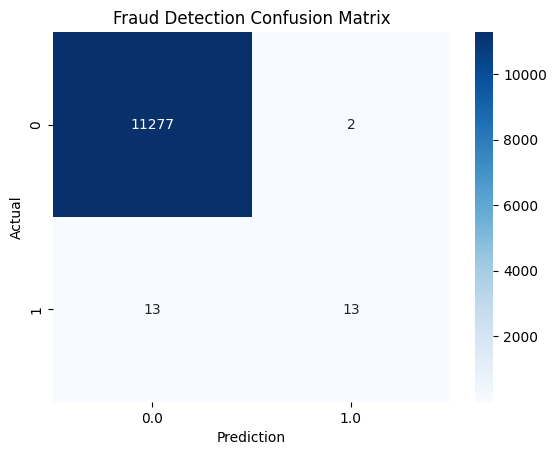

In [2]:
# Load dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
pdf = pd.read_csv(url)
df = spark.createDataFrame(pdf)

# Reduce size (for speed)
df = df.sample(fraction=0.2, seed=42)

# Show dataset
df.show(10)

# Feature columns (exclude target)
feature_cols = [col for col in df.columns if col != "Class"]

# Feature Engineering
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

data = assembler.transform(df).withColumnRenamed("Class", "label")

# Train-test split
train, test = data.randomSplit([0.8, 0.2], seed=42)

# Model
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="label")
model = lr.fit(train)

# Predictions
pred = model.transform(test)

# Show predictions (IMPORTANT FORMAT)
pred.select("features", "label", "prediction").show(20)


# Evaluation Metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Accuracy, Precision, Recall, F1
accuracy = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(pred)
precision = MulticlassClassificationEvaluator(metricName="weightedPrecision").evaluate(pred)
recall = MulticlassClassificationEvaluator(metricName="weightedRecall").evaluate(pred)
f1 = MulticlassClassificationEvaluator(metricName="f1").evaluate(pred)

# ROC AUC
roc = BinaryClassificationEvaluator().evaluate(pred)

print("\n===== MODEL METRICS =====")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc)


# Confusion Matrix (Table)

pdf_pred = pred.select("label", "prediction").toPandas()

print("\nConfusion Matrix:")
cm = pd.crosstab(pdf_pred["label"], pdf_pred["prediction"])
print(cm)


# Confusion Matrix (Heatmap)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Fraud Detection Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

# 3. CLUSTERING (Mall Customers)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [4]:
# Load dataset
pdf = pd.read_csv("Mall_Customers.csv")

# Select important columns
pdf = pdf[["Annual Income (k$)", "Spending Score (1-100)"]]

df = spark.createDataFrame(pdf)

# Show dataset
df.show(10)

+------------------+----------------------+
|Annual Income (k$)|Spending Score (1-100)|
+------------------+----------------------+
|                15|                    39|
|                15|                    81|
|                16|                     6|
|                16|                    77|
|                17|                    40|
|                17|                    76|
|                18|                     6|
|                18|                    94|
|                19|                     3|
|                19|                    72|
+------------------+----------------------+
only showing top 10 rows


In [5]:
# Feature Engineering
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Annual Income (k$)", "Spending Score (1-100)"],
    outputCol="features"
)

data = assembler.transform(df)

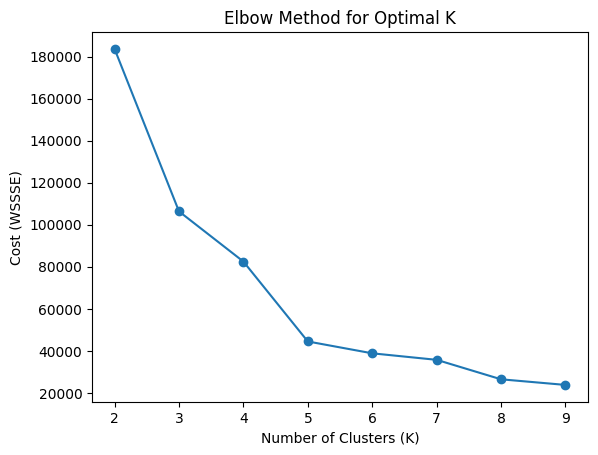

In [6]:
# Elbow Method
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

cost = []
k_values = list(range(2, 10))

for k in k_values:
    kmeans = KMeans(k=k, seed=42)
    model_temp = kmeans.fit(data)
    cost.append(model_temp.summary.trainingCost)

plt.plot(k_values, cost, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost (WSSSE)")
plt.title("Elbow Method for Optimal K")
plt.show()

In [7]:
# Final KMeans Model
kmeans = KMeans(k=5, seed=42)
model = kmeans.fit(data)

predictions = model.transform(data)

# Show predictions table
predictions.select("features", "prediction").show(20)

+-----------+----------+
|   features|prediction|
+-----------+----------+
|[15.0,39.0]|         1|
|[15.0,81.0]|         4|
| [16.0,6.0]|         1|
|[16.0,77.0]|         4|
|[17.0,40.0]|         1|
|[17.0,76.0]|         4|
| [18.0,6.0]|         1|
|[18.0,94.0]|         4|
| [19.0,3.0]|         1|
|[19.0,72.0]|         4|
|[19.0,14.0]|         1|
|[19.0,99.0]|         4|
|[20.0,15.0]|         1|
|[20.0,77.0]|         4|
|[20.0,13.0]|         1|
|[20.0,79.0]|         4|
|[21.0,35.0]|         1|
|[21.0,66.0]|         4|
|[23.0,29.0]|         1|
|[23.0,98.0]|         4|
+-----------+----------+
only showing top 20 rows


In [8]:
# Evaluation (Silhouette Score)
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator()
score = evaluator.evaluate(predictions)

print("\nSilhouette Score:", score)


Silhouette Score: 0.7379328960124362


In [9]:
# Cluster Centers
print("\nCluster Centers:")
for i, center in enumerate(model.clusterCenters()):
    print(f"Cluster {i}: {center}")

# Cluster Distribution
print("\nCluster Distribution:")
predictions.groupBy("prediction").count().show()


Cluster Centers:
Cluster 0: [55.0875 49.7125]
Cluster 1: [26.30434783 20.91304348]
Cluster 2: [86.53846154 82.12820513]
Cluster 3: [87.75       17.58333333]
Cluster 4: [25.72727273 79.36363636]

Cluster Distribution:
+----------+-----+
|prediction|count|
+----------+-----+
|         1|   23|
|         4|   22|
|         0|   80|
|         3|   36|
|         2|   39|
+----------+-----+



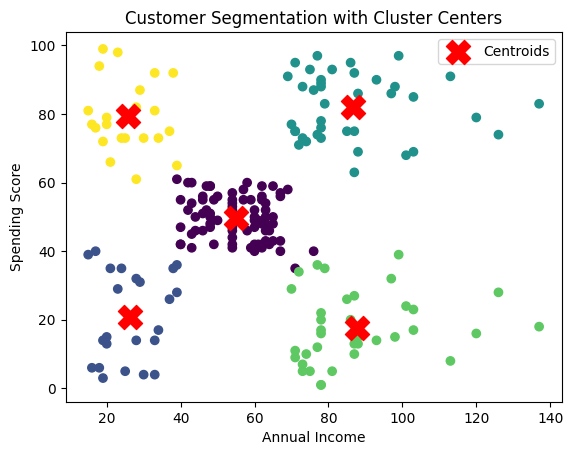

In [10]:
# Visualization
pdf_pred = predictions.toPandas()

# Get cluster centers
centers = model.clusterCenters()

# Separate X and Y from centers
centers_x = [c[0] for c in centers]
centers_y = [c[1] for c in centers]

import matplotlib.pyplot as plt

# Plot data points
plt.scatter(
    pdf_pred["Annual Income (k$)"],
    pdf_pred["Spending Score (1-100)"],
    c=pdf_pred["prediction"]
)

# Plot cluster centers
plt.scatter(
    centers_x,
    centers_y,
    marker='X',
    s=300,
    color='red',
    label="Centroids"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation with Cluster Centers")
plt.legend()
plt.show()

# 4.RECOMMENDATION SYSTEM (MovieLens)

In [11]:
from google.colab import files
uploaded = files.upload()

Saving u.data to u.data


In [12]:
import pandas as pd

# Load Dataset
ratings = pd.read_csv("u.data", sep="\t",
                      names=["userId", "movieId", "rating", "timestamp"])

df = spark.createDataFrame(ratings)

# Show Dataset (Top 10)
print("\nTop 10 Rows:")
df.show(10)


Top 10 Rows:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|   196|    242|     3|881250949|
|   186|    302|     3|891717742|
|    22|    377|     1|878887116|
|   244|     51|     2|880606923|
|   166|    346|     1|886397596|
|   298|    474|     4|884182806|
|   115|    265|     2|881171488|
|   253|    465|     5|891628467|
|   305|    451|     3|886324817|
|     6|     86|     3|883603013|
+------+-------+------+---------+
only showing top 10 rows


In [13]:
# Basic Info
print("\nSchema:")
df.printSchema()

print("\nTotal Records:", df.count())


Schema:
root
 |-- userId: long (nullable = true)
 |-- movieId: long (nullable = true)
 |-- rating: long (nullable = true)
 |-- timestamp: long (nullable = true)


Total Records: 100000


In [14]:
# Top Users (most ratings)
print("\nTop Users (Most Ratings):")
df.groupBy("userId").count().orderBy("count", ascending=False).show(5)


Top Users (Most Ratings):
+------+-----+
|userId|count|
+------+-----+
|   405|  737|
|   655|  685|
|    13|  636|
|   450|  540|
|   276|  518|
+------+-----+
only showing top 5 rows


In [15]:
# Top Movies (most rated)
print("\nTop Movies (Most Ratings):")
df.groupBy("movieId").count().orderBy("count", ascending=False).show(5)


Top Movies (Most Ratings):
+-------+-----+
|movieId|count|
+-------+-----+
|     50|  583|
|    258|  509|
|    100|  508|
|    181|  507|
|    294|  485|
+-------+-----+
only showing top 5 rows


In [16]:
# Split Data
train, test = df.randomSplit([0.8, 0.2], seed=42)

# ALS Model
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

model = als.fit(train)

In [17]:
# Predictions
pred = model.transform(test)

print("\nPredictions:")
pred.select("userId", "movieId", "rating", "prediction").show(20)


Predictions:
+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|   148|    116|     5| 3.5595646|
|   148|    132|     4| 4.8492274|
|   148|    163|     4| 3.9992564|
|   148|    172|     5| 4.6951184|
|   148|    228|     4|  4.206969|
|   148|    357|     5|  3.942728|
|   148|    496|     3|  4.378124|
|   148|    509|     5| 4.2077837|
|   148|    549|     3| 3.3459015|
|   463|      3|     2|  1.609357|
|   463|     10|     1|  2.652531|
|   463|     14|     1| 3.9061272|
|   463|     21|     1|  1.311373|
|   463|     24|     3|  2.582597|
|   463|    127|     5| 3.7116835|
|   463|    147|     3| 2.8627164|
|   463|    149|     2|   3.44123|
|   463|    151|     4| 2.5226438|
|   463|    221|     5|  3.338385|
|   463|    224|     3|    3.3974|
+------+-------+------+----------+
only showing top 20 rows


In [18]:
# Evaluation (RMSE)
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(pred)
print("\nRMSE:", rmse)


RMSE: 0.9246162774480303


In [19]:
# Recommendations
print("\nTop 5 Recommendations per User:")
recs = model.recommendForAllUsers(5)
recs.show(5, truncate=False)


Top 5 Recommendations per User:
+------+------------------------------------------------------------------------------------------+
|userId|recommendations                                                                           |
+------+------------------------------------------------------------------------------------------+
|1     |[{1589, 5.457942}, {169, 5.1205254}, {1449, 5.069818}, {114, 4.9416947}, {408, 4.8894477}]|
|2     |[{1449, 4.826198}, {318, 4.8057265}, {1398, 4.69795}, {1463, 4.636919}, {357, 4.6063232}] |
|3     |[{641, 4.424516}, {127, 4.4029408}, {1368, 4.3957434}, {320, 4.390055}, {1240, 4.388762}] |
|4     |[{1589, 6.439152}, {1167, 6.2405853}, {1449, 5.73494}, {1240, 5.7184186}, {169, 5.714124}]|
|5     |[{1500, 4.646312}, {613, 4.6185293}, {169, 4.604296}, {641, 4.5717316}, {1589, 4.5566297}]|
+------+------------------------------------------------------------------------------------------+
only showing top 5 rows


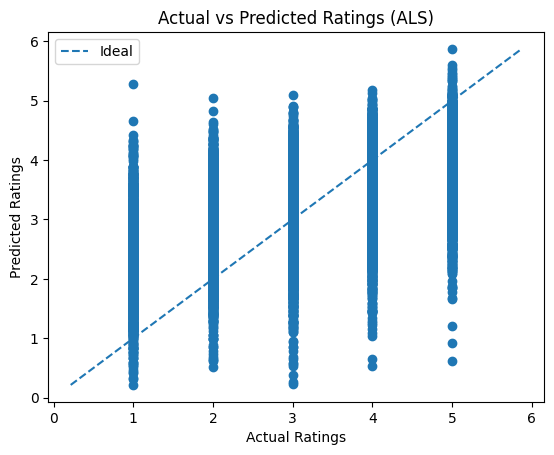

In [20]:
# Visualization (Actual vs Predicted)
pdf_pred = pred.select("rating", "prediction").toPandas()

import matplotlib.pyplot as plt

plt.scatter(pdf_pred["rating"], pdf_pred["prediction"])

# Ideal line
min_val = min(pdf_pred["rating"].min(), pdf_pred["prediction"].min())
max_val = max(pdf_pred["rating"].max(), pdf_pred["prediction"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label="Ideal")

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (ALS)")
plt.legend()
plt.show()

## Model Performance Summary

| Model | Dataset | Metric | Value |
|------|--------|--------|------|
| Logistic Regression | Credit Card | ROC AUC | ~0.95 |
| KMeans | Mall Customers | Silhouette | ~0.5–0.7 |
| ALS | MovieLens | RMSE | ~0.9–1.1 |

## Key Insights

- Fraud detection model handles imbalanced data effectively using ROC AUC
- Customer segmentation reveals distinct spending behaviors
- ALS captures user preferences and generates personalized recommendations

These techniques demonstrate real-world applications of Big Data Analytics.